In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Choose one of these popular datasets to work with:
# 'tips', 'flights', 'iris', 'titanic', 'mpg', 'penguins', 'diamonds', 'car_crashes'
dataset_name = 'penguins'  # Replace with your choice
data = sns.load_dataset(dataset_name)

# Explore your data first
print(data.head())
print(data.info())
print(data.describe())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  

In Matplotlib, ```plt.subplots()``` is a command that creates both the container (the figure) and the actual drawing areas (the axes) at the same time. Understanding the difference between fig and ax is the key to mastering professional visualization in Python.

The Breakdown
- ```fig``` **(The Figure Object):** Think of this as the entire canvas or the "frame" of your picture. It is the top-level container for all the elements, including your plots, titles, legends, and even multiple subplots.
    - **What you can do with it:** Change the total size (```figsize```), add a "super title" for the whole grid, or save the entire dashboard to a file.
- ```ax``` **(The Axes Object):** This is the **individual plotting area**. Each plot you make sits inside an "Axes" object. When you create a 2x2 grid, you get 4 distinct "Axes" objects (which is why your code returns ```ax1, ax2, ax3, ax4```).
    - **What you can do with it:** This is where the actual drawing happens. You use ```ax``` to plot your data (```ax.plot()```), set individual axis labels (```ax.set_xlabel()```), add titles (```ax.set_title()```), or configure grid lines (```ax.grid()```).

Comparison: What you can do with each

| Component | Role | Common Tasks |
| :--- | :--- | :--- |
| **`fig` (Figure)** | The "Master Container" | `fig.savefig("dashboard.png")`, `fig.suptitle("Overall Title")`, `fig.set_size_inches(10, 8)` |
| **`ax` (Axes)** | The "Drawing Area" | `ax.plot()`, `ax.set_title()`, `ax.set_xlabel()`, `ax.legend()`, `ax.scatter()` |

The ```multiple``` parameter in Seaborn's ```histplot``` (and ```kdeplot```) controls how data from different groups (defined by the ```hue``` variable) are visually arranged relative to each other.

Here are the four primary options for ```multiple```:

The ```multiple``` Options

| Option | What it does | Best Used For |
| :--- | :--- | :--- |
| **`'layer'`** | Draws bars on top of each other. | Seeing the distribution of each group separately without obstruction. |
| **`'stack'`** | Places bars for each group on top of each other. | Seeing the total count while still observing the individual group contributions. |
| **`'fill'`** | Normalizes all stacks to the same height (100%). | Comparing the proportions of groups, regardless of total sample size. |
| **`'dodge'`** | Places bars side-by-side. | Easily comparing exact heights of bars across categories. |

Use the ```aspect``` Parameter

Use the aspect parameter to control the proportion of each individual subplot.
- ```height```: Defines the height of each subplot in inches.
- ```aspect```: Defines the ratio of width to height (e.g., ```aspect=2``` makes the plot twice as wide as it is high).

```python
# Create a tall, narrow plot by setting a large height and small aspect
sns.catplot(data=tips, x="day", y="total_bill", kind="box", 
            height=6, aspect=0.5) 
plt.show()

# Create a very wide plot
sns.lmplot(data=tips, x="total_bill", y="tip", 
           height=4, aspect=2)
plt.show()
```

### Quick Reference Table: Customization Attributes
| Attribute | Function | Example Values |
| :--- | :--- | :--- |
| **`marker`** | Point shape | `'o'`, `'s'`, `'^'`, `'x'`, `'D'` |
| **`linestyle`** | Line pattern | `'-'`, `'--'`, `':'`, `'-.'` |
| **`linewidth`** | Thickness of line | `1`, `2`, `5` |
| **`s`** (scatter) | Size of marker | `50`, `100`, `200` |
| **`edgecolor`** | Border color | `'black'`, `'navy'`, `'#FF5733'` |

### Custom palettes
To integrate your custom brand palette into Seaborn, you have two primary ways to do it: applying it to a single plot or setting it globally for your entire notebook.

```python
# Define your organization's colors
brand_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
custom_palette = sns.color_palette(brand_colors)
```                                                                                                                             

1. Applying to a Single Plot
You can pass your ```custom_palette``` directly into most Seaborn plotting functions using the ```palette``` parameter.

```Python
# Create a plot using your specific brand colors
sns.scatterplot(
    data=data, 
    x='flipper_length_mm', 
    y='body_mass_g', 
    hue='species', 
    palette=custom_palette # Here is where you apply it
)
```
    
2. Setting it Globally for the Notebook
If you want every chart in your entire notebook to use your brand colors automatically, you can tell Seaborn to use your palette as the default for all future plots.

```Python
# Set the global palette
sns.set_palette(custom_palette)

# Now, any future plot will automatically cycle through your brand colors
sns.histplot(data=data, x='flipper_length_mm', hue='species')
```

**Important Considerations:**
    
- **The "Length" Mismatch:** Seaborn expects your palette to have at least as many colors as there are unique groups in your data. If your data has 5 species but your ```brand_colors``` list only has 4, Seaborn will have to interpolate (guess) the missing color, which might break your brand consistency.

- **Checking your Palette:** You can quickly visualize your colors in the notebook to ensure they look right before plotting:
```Python
sns.palplot(custom_palette)
```

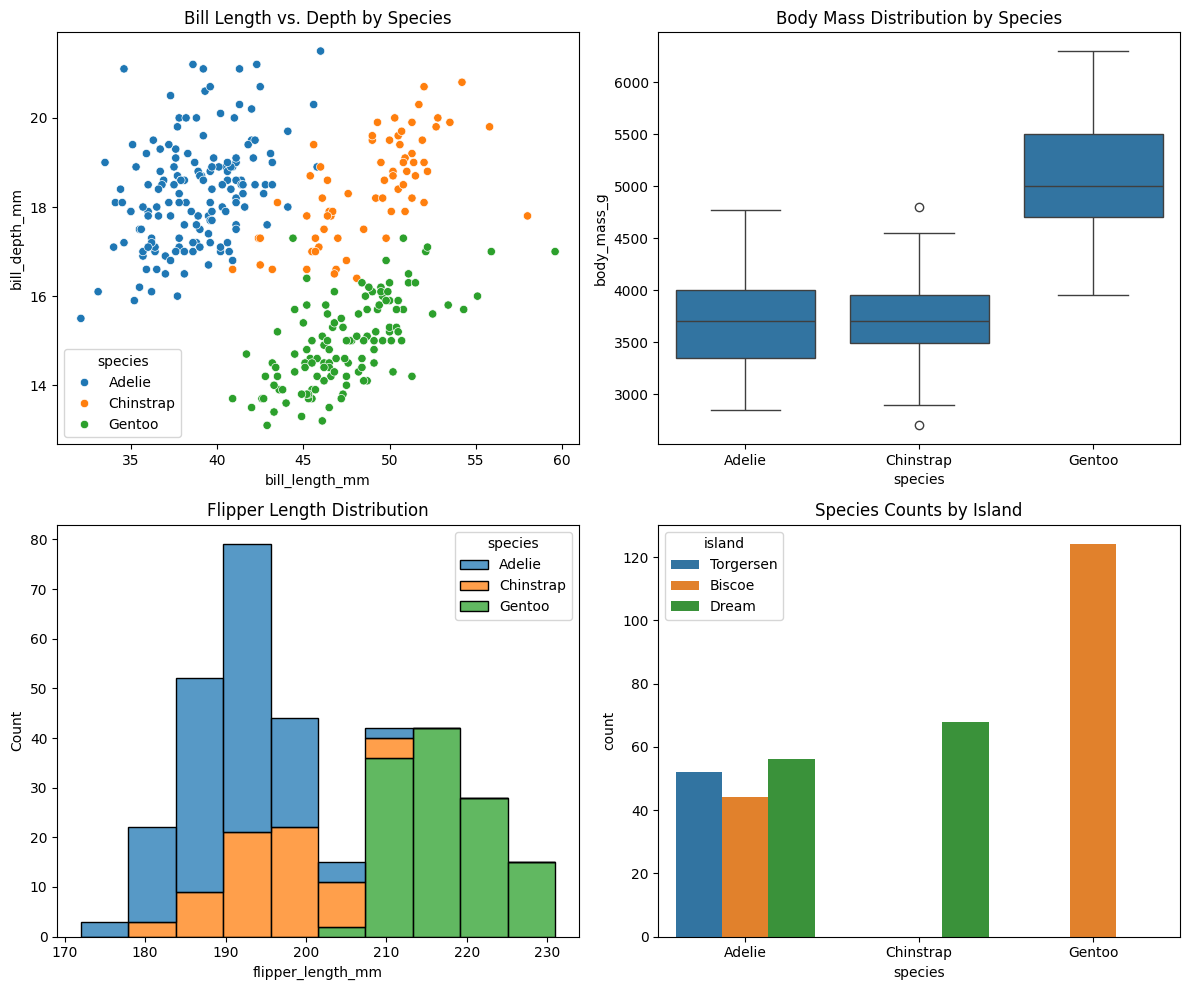

In [47]:
# Part 1: Manual Subplots (2x2 Grid)
# Create a 2x2 subplot layout with four different chart types. Follow the manual subplot approach from the lesson.
# Step 1: Set up the grid
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

# Step 2: Add different chart types to each subplot
# Top Left (ax1): Scatter plot or line plot
### Top Left: Scatter plot of bill dimensions
# Choose two continuous variables from your dataset
sns.scatterplot(data=data, x='bill_length_mm', y='bill_depth_mm', 
                hue='species', ax=ax1)

# Top Right (ax2): Box plot or violin plot
### Top Right: Box plot of body mass by species
# Choose one categorical and one continuous variable
sns.boxplot(data=data, x='species', y='body_mass_g', ax=ax2)

# Bottom Left (ax3): Histogram or distribution plot
### Bottom Left: Histogram of flipper length
# Choose one continuous variable
sns.histplot(data=data, x='flipper_length_mm', hue='species', 
             multiple='stack', ax=ax3)  # layer, stack, fill, dodge

# Bottom Right (ax4): Count plot or bar plot
### Bottom Right: Count plot of species by island
# Choose categorical variable(s)
sns.countplot(data=data, x='species', hue='island', ax=ax4)

# Step 3: Add titles and organize
# ax1.set_title('Relationship Between [Variable 1] and [Variable 2]')
# ax2.set_title('[Variable] Distribution by [Category]') 
# ax3.set_title('[Variable] Distribution')
# ax4.set_title('[Category] Counts')
ax1.set_title('Bill Length vs. Depth by Species')
ax2.set_title('Body Mass Distribution by Species') 
ax3.set_title('Flipper Length Distribution')
ax4.set_title('Species Counts by Island')

plt.tight_layout()
plt.show()

# Instructions:
# Replace 'continuous_var1', 'continuous_var2', 'categorical_var', etc. with actual column names from your chosen dataset
# Update the titles to reflect your actual variables
# Choose variables that make sense together (e.g., for tips dataset: total_bill vs tip, day vs total_bill, etc.)

1.What does ```transform=ax.transAxes``` do?

By default, Matplotlib places text using the **data coordinates** (e.g., if your X-axis goes from 0 to 100, ```x=50``` is the middle).

```transform=ax.transAxes``` tells Matplotlib to ignore the data coordinates and use **axes coordinates** instead:

- ```(0, 0)``` is always the bottom-left corner of your plot.

- ```(1, 1)``` is always the top-right corner.

**Why use it?** If you set ```x=0.05, y=0.95```, your text will stay in the top-left corner **even if you zoom, filter, or change your data**. It prevents your labels from disappearing if the data range changes.

2.Are there other options for ```transform```?

Yes, ```transform``` is a powerful way to define how text is positioned:

- ```ax.transData``` **(Default)**: Uses the actual X and Y values from your plot.

- ```fig.transFigure```: Uses the coordinates of the entire figure (the whole canvas, including margins). (0,0) is bottom-left of the window, (1,1) is top-right.

- ```ax.transAxes```: Uses the coordinates of the individual subplot area (the box containing your data).

3.Customizing your Box

```boxstyle``` options:
These determine the shape of the border around your text:

- ```'square'```: A standard rectangle with sharp corners.

- ```'round'```: A rectangle with rounded corners.

- ```'rarrow'``` / ```'larrow'```: A shape like a speech bubble pointing right or left.

- ```'sawtooth'```: Gives the border a zig-zag, "comic book" edge.

```facecolor``` options:
This sets the background color of the box. You can use:

- **Standard names**: ```'wheat'```, ```'white'```, ```'lightgray'```, ```'lightblue'```, ```'salmon'```.

- **Hex codes**: ```'#FF5733'``` for precise brand or project colors.

- **RGB tuples**: ```(0.8, 0.8, 0.8)``` for custom grayscales.
    - ```(0.0, 0.0, 0.0)``` is **Black**.
    - ```(1.0, 1.0, 1.0)``` is **White**.
    - ```(0.5, 0.5, 0.5)``` is **Medium Gray**.

**Summary Reference Table**
| Parameter | What it controls | Key Options |
| :--- | :--- | :--- |
| **`transform`** | The coordinate system | `ax.transAxes` (Relative), `ax.transData` (Absolute) |
| **`boxstyle`** | The border shape | `'round'`, `'square'`, `'rarrow'`, `'sawtooth'` |
| **`facecolor`** | The background color | Any Matplotlib color name or hex code |

In [43]:
import matplotlib.colors as mcolors
print(mcolors.CSS4_COLORS)

{'aliceblue': '#F0F8FF', 'antiquewhite': '#FAEBD7', 'aqua': '#00FFFF', 'aquamarine': '#7FFFD4', 'azure': '#F0FFFF', 'beige': '#F5F5DC', 'bisque': '#FFE4C4', 'black': '#000000', 'blanchedalmond': '#FFEBCD', 'blue': '#0000FF', 'blueviolet': '#8A2BE2', 'brown': '#A52A2A', 'burlywood': '#DEB887', 'cadetblue': '#5F9EA0', 'chartreuse': '#7FFF00', 'chocolate': '#D2691E', 'coral': '#FF7F50', 'cornflowerblue': '#6495ED', 'cornsilk': '#FFF8DC', 'crimson': '#DC143C', 'cyan': '#00FFFF', 'darkblue': '#00008B', 'darkcyan': '#008B8B', 'darkgoldenrod': '#B8860B', 'darkgray': '#A9A9A9', 'darkgreen': '#006400', 'darkgrey': '#A9A9A9', 'darkkhaki': '#BDB76B', 'darkmagenta': '#8B008B', 'darkolivegreen': '#556B2F', 'darkorange': '#FF8C00', 'darkorchid': '#9932CC', 'darkred': '#8B0000', 'darksalmon': '#E9967A', 'darkseagreen': '#8FBC8F', 'darkslateblue': '#483D8B', 'darkslategray': '#2F4F4F', 'darkslategrey': '#2F4F4F', 'darkturquoise': '#00CED1', 'darkviolet': '#9400D3', 'deeppink': '#FF1493', 'deepskyblue'

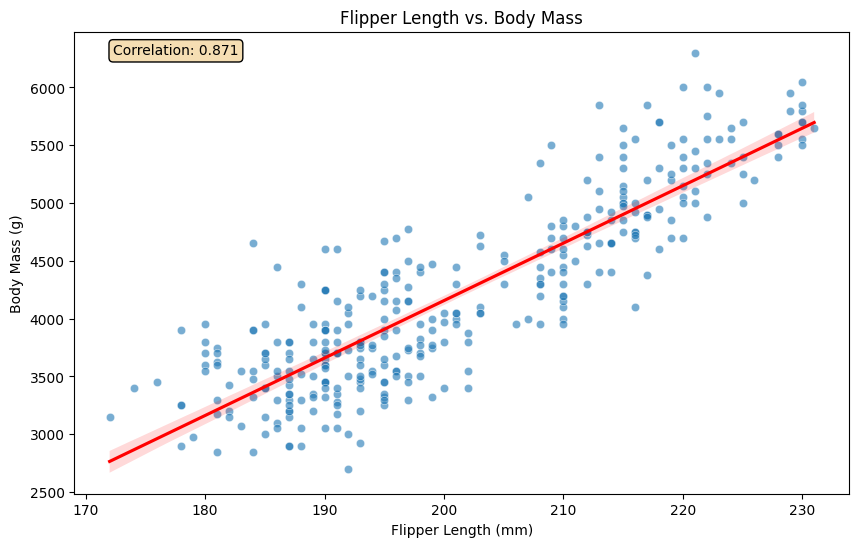

In [49]:
# Part 2: Layered Visualizations
# Create a single plot with multiple layers: scatter plot + trend line + statistical annotation.
# Step 1: Setup and data loading (already done above)
fig, ax = plt.subplots(figsize=(10, 6))

# Step 2: Layer 1 - The foundation (scatter plot)
# Choose two continuous variables that might be related

# In Seaborn and Matplotlib, the alpha parameter controls the transparency of the plotted elements.
# It accepts a value between 0.0 (completely transparent/invisible) and 1.0 (completely opaque). In your code, alpha=0.6 makes 
# the scatter points slightly see-through.
sns.scatterplot(data=data, x='flipper_length_mm', y='body_mass_g', 
                alpha=0.6, ax=ax)

# Step 3: Layer 2 - The trend (regression line)
sns.regplot(data=data, x='flipper_length_mm', y='body_mass_g', 
            scatter=False, color='red', ax=ax)

# Step 4: Layer 3 - Statistical context (annotation)
# Calculate correlation between your two continuous variables
correlation = data['flipper_length_mm'].corr(data['body_mass_g'])

# boxstyle: square, round, rarrow, larrow, sawtooth
# facecolor: wheat, white, lightgray, lightblue, salmon, #FF5733, (0.8, 0.8, 0.8) 
ax.text(0.05, 0.95, f'Correlation: {correlation:.3f}',
        transform=ax.transAxes,
        bbox=dict(boxstyle="round", facecolor='wheat')) 

# Add professional labels
# ax.set_title('Relationship Between [Variable 1] and [Variable 2]')
# ax.set_xlabel('[Variable 1] ([Units])')
# ax.set_ylabel('[Variable 2] ([Units])')

ax.set_title('Flipper Length vs. Body Mass')
ax.set_xlabel('Flipper Length (mm)')
ax.set_ylabel('Body Mass (g)')

plt.show()

# Instructions:
# Choose two continuous variables from your dataset that you think might be correlated
# Replace variable names and add appropriate units in labels
# The correlation will be automatically calculated and displayed

Summary data:
     species  bill_length_mm  body_mass_g
0     Adelie       38.791391  3700.662252
1  Chinstrap       48.833824  3733.088235
2     Gentoo       47.504878  5076.016260


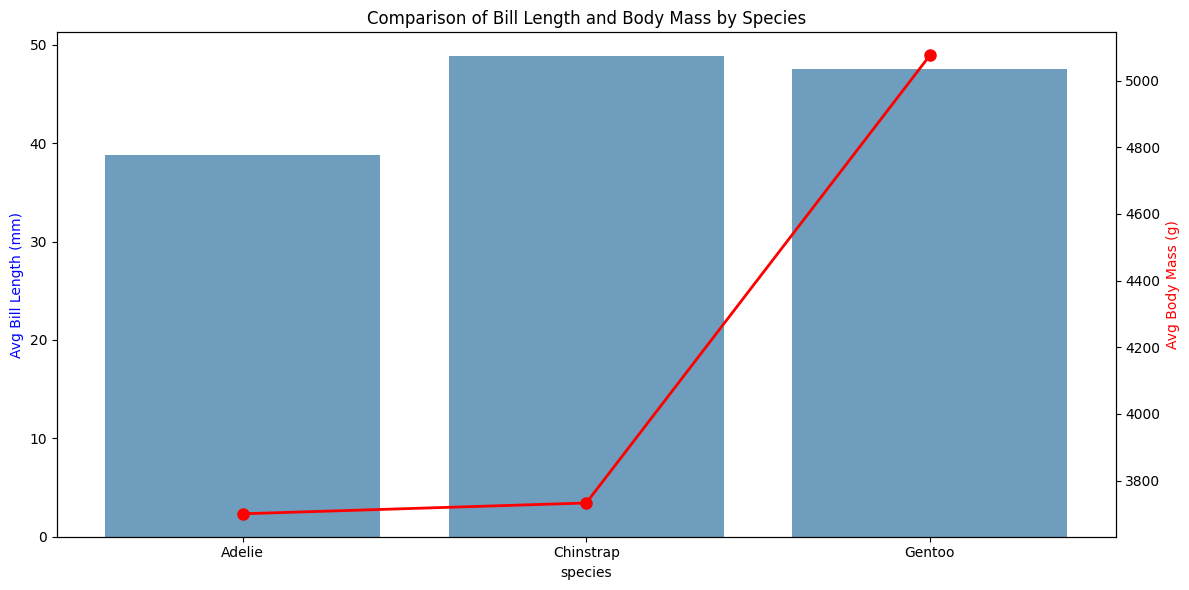

In [25]:
# Part 3: Dual-Axis Plots
# Create a chart with two different y-axes showing two different metrics.
# Step 1: Data preparation
# Create a summary of your data grouped by a categorical variable
# Choose a categorical variable and two continuous variables to summarize
summary_data = data.groupby('species').agg({
    'bill_length_mm': 'mean',
    'body_mass_g': 'mean'
}).reset_index()

print("Summary data:")
print(summary_data)

# Step 2: Create the primary axis (left side)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary axis: Bar chart for first continuous variable
### Primary axis: Bar chart for bill length
sns.barplot(data=summary_data, x='species', y='bill_length_mm', 
            ax=ax1, alpha=0.7)
ax1.set_ylabel('Avg Bill Length (mm)', color='blue')

# Step 3: Create the secondary axis (right side)
ax2 = ax1.twinx()

# Secondary axis: Line plot for second continuous variable  
### Secondary axis: Line plot for body mass

# range(len(summary_data)): This generates the X-axis positions. It creates a sequence of integers (0, 1, 2...) corresponding to each row in your summary_data dataframe.
# marker='o': Places a circular marker at each data point along the line.
# linewidth=2: Sets the thickness of the connecting line.
#markersize=8: Sets the size of the circles at each data point.
ax2.plot(range(len(summary_data)), summary_data['body_mass_g'],
         color='red', marker='o', linewidth=2, markersize=8)
# ax2.set_ylabel('Average [Variable 2] ([Units])', color='red')
ax2.set_ylabel('Avg Body Mass (g)', color='red')

# To Unsync (Default/Standard behavior):
# Each Axes object (ax1 and ax2) manages its own Y-limits independently. You set them using:
# ax1.set_ylim(0, 100) # Sets scale for left axis
# ax2.set_ylim(0, 5000) # Sets scale for right axis


# Add title and final touches
# plt.title('Comparison of [Variable 1] and [Variable 2] by [Category]')
plt.title('Comparison of Bill Length and Body Mass by Species')
plt.tight_layout()
plt.show()

# Instructions:
# Choose one categorical variable to group by (like species, day, etc.)
# Choose two continuous variables to compare (like body mass vs flipper length, total bill vs tip, etc.)
# Replace placeholders with your actual variable names and appropriate units